<a href="https://colab.research.google.com/github/bismarxx/Machine-Learning-I-Actividad-7/blob/main/Ejercicio4_clustering_lineal_vs_no_lineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelos de clustering: naturaleza lineal o no lineal e hiperparametros criticos

**Objetivo:** determinar cuales de los modelos K-means, DBSCAN y SpectralClustering son de naturaleza lineal y cuales no lineal, e identificar los hiperparametros criticos para su entrenamiento exitoso. Cada afirmacion se respalda con un experimento sobre el dataset sintetico `circles`.

**Criterio:** en clustering, "lineal" o "no lineal" se refiere a la forma de la frontera que el algoritmo puede trazar entre los grupos. Un modelo es lineal si solo puede separar grupos con hiperplanos (rectas en 2D), y no lineal si puede separar grupos con fronteras de forma arbitraria.

Contenido:
1. Resumen teorico
2. Datos y modelos base
3. Prueba de naturaleza lineal (fronteras y separabilidad lineal)
4. Hiperparametros criticos de K-means
5. Hiperparametros criticos de DBSCAN
6. Hiperparametros criticos de SpectralClustering
7. Costo computacional
8. Conclusiones

## 1. Resumen teorico

| Modelo | Naturaleza | Por que | Hiperparametros criticos |
|---|---|---|---|
| K-means | Lineal | La frontera entre dos clusters es la mediatriz entre sus centroides, por lo que el espacio queda dividido en regiones convexas (diagrama de Voronoi) | `n_clusters`, `n_init`, `init` |
| DBSCAN | No lineal | Agrupa por conectividad de densidad, por lo que los clusters pueden tener cualquier forma | `eps`, `min_samples` |
| SpectralClustering | No lineal | Proyecta los puntos al espacio espectral de un grafo de vecindad y agrupa alli, lo que produce fronteras no lineales en el espacio original | `n_clusters`, `affinity`, `n_neighbors` (o `gamma`) |

Los experimentos siguientes verifican estas afirmaciones.

## 0. Librerias

In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.dpi"] = 110

## 2. Datos y modelos base

Se usa el mismo dataset `circles` (dos circulos concentricos, 1000 puntos) estandarizado con `StandardScaler`. Las etiquetas reales `y_true` no se usan para entrenar, solo para calcular el ARI (Adjusted Rand Index), que vale 1 cuando el agrupamiento coincide con la estructura real y cerca de 0 cuando es equivalente al azar.

Tambien se genera un dataset `blobs` (grupos compactos y convexos) para contrastar el comportamiento de K-means cuando los grupos si son separables linealmente.

In [2]:
X_raw, y_true = make_circles(n_samples=1000, factor=0.5, noise=0.05, random_state=RANDOM_STATE)
X = StandardScaler().fit_transform(X_raw)

Xb_raw, yb_true = make_blobs(n_samples=600, centers=3, cluster_std=0.7, random_state=7)
Xb = StandardScaler().fit_transform(Xb_raw)

print("circles:", X.shape, "| blobs:", Xb.shape)

circles: (1000, 2) | blobs: (600, 2)


In [3]:
def ajustar_spectral(**kwargs):
    """Entrena SpectralClustering silenciando la advertencia esperada de grafo no conexo."""
    modelo = SpectralClustering(random_state=RANDOM_STATE, **kwargs)
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UserWarning)
        return modelo.fit_predict(X)


kmeans = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit(X)
labels_kmeans = kmeans.labels_
labels_dbscan = DBSCAN(eps=0.2, min_samples=5).fit_predict(X)
labels_spectral = ajustar_spectral(
    n_clusters=2, affinity="nearest_neighbors", n_neighbors=10, assign_labels="kmeans"
)

base = {
    "K-means": labels_kmeans,
    "DBSCAN": labels_dbscan,
    "SpectralClustering": labels_spectral,
}

for nombre, etiquetas in base.items():
    print(f"{nombre:<20} ARI = {metrics.adjusted_rand_score(y_true, etiquetas):.3f}")

K-means              ARI = -0.001
DBSCAN               ARI = 1.000
SpectralClustering   ARI = 1.000


## 3. Prueba de naturaleza lineal

### 3.1 Regiones de decision

Para visualizar la frontera de cada modelo se colorea el plano con la region que asignaria cada uno:

- **K-means:** se usa `predict` sobre una malla de puntos (asigna cada punto al centroide mas cercano).
- **DBSCAN y SpectralClustering:** no tienen `predict`, por lo que la region se aproxima asignando cada punto de la malla al cluster de su vecino mas cercano entre los puntos ya agrupados (1-NN). Es una aproximacion visual de la forma de la frontera, no la definicion exacta del algoritmo.

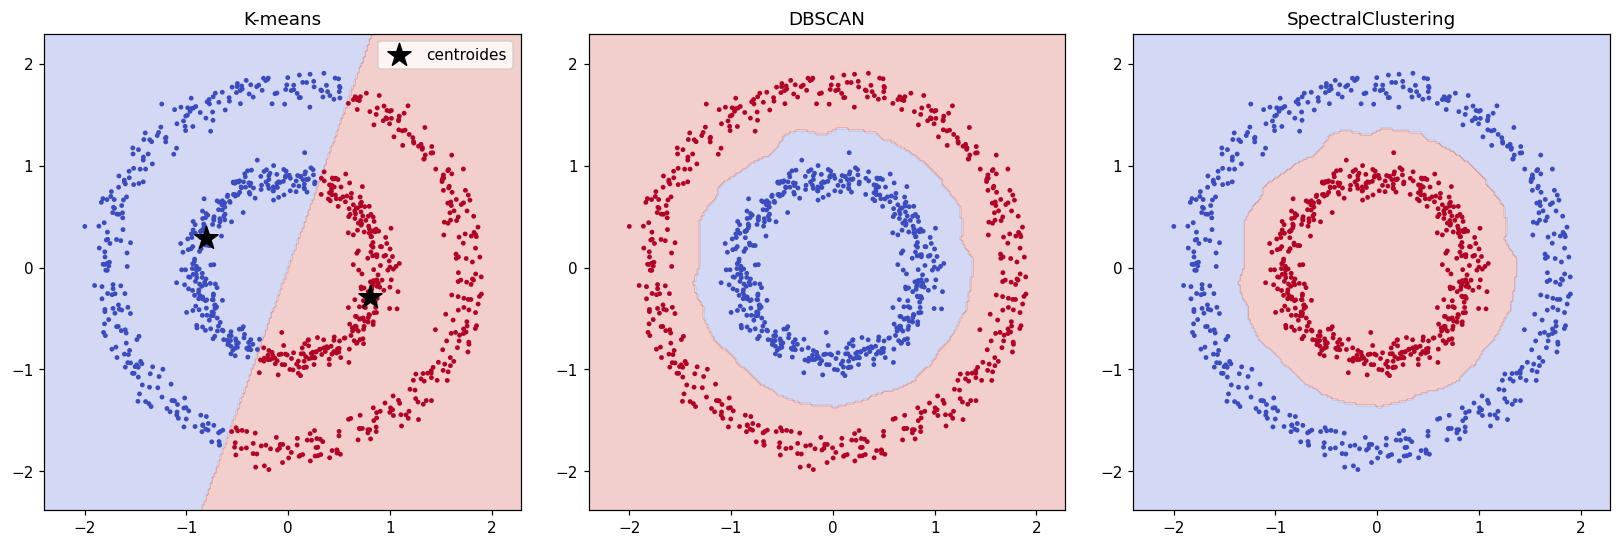

In [4]:
def malla(X, paso=0.02, margen=0.4):
    x_min, x_max = X[:, 0].min() - margen, X[:, 0].max() + margen
    y_min, y_max = X[:, 1].min() - margen, X[:, 1].max() + margen
    xx, yy = np.meshgrid(np.arange(x_min, x_max, paso), np.arange(y_min, y_max, paso))
    return xx, yy


def region_por_vecino(X, etiquetas, puntos):
    valido = etiquetas != -1
    vecino = KNeighborsClassifier(n_neighbors=1).fit(X[valido], etiquetas[valido])
    return vecino.predict(puntos)


xx, yy = malla(X)
puntos = np.c_[xx.ravel(), yy.ravel()]

regiones = {
    "K-means": kmeans.predict(puntos),
    "DBSCAN": region_por_vecino(X, labels_dbscan, puntos),
    "SpectralClustering": region_por_vecino(X, labels_spectral, puntos),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, (nombre, region) in zip(axes, regiones.items()):
    ax.contourf(xx, yy, region.reshape(xx.shape), alpha=0.25, cmap="coolwarm")
    etiquetas = base[nombre]
    ruido = etiquetas == -1
    ax.scatter(X[~ruido, 0], X[~ruido, 1], c=etiquetas[~ruido], cmap="coolwarm", s=10, edgecolor="none")
    if ruido.any():
        ax.scatter(X[ruido, 0], X[ruido, 1], c="black", marker="x", s=25)
    if nombre == "K-means":
        ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                   c="black", marker="*", s=250, label="centroides")
        ax.legend(loc="upper right")
    ax.set_title(nombre)
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

### 3.2 Contraste: K-means si funciona cuando los grupos son convexos

Que K-means sea lineal no significa que sea un mal modelo: es adecuado cuando los grupos son compactos y se pueden separar con rectas. Se compara su comportamiento en `blobs` y en `circles`.

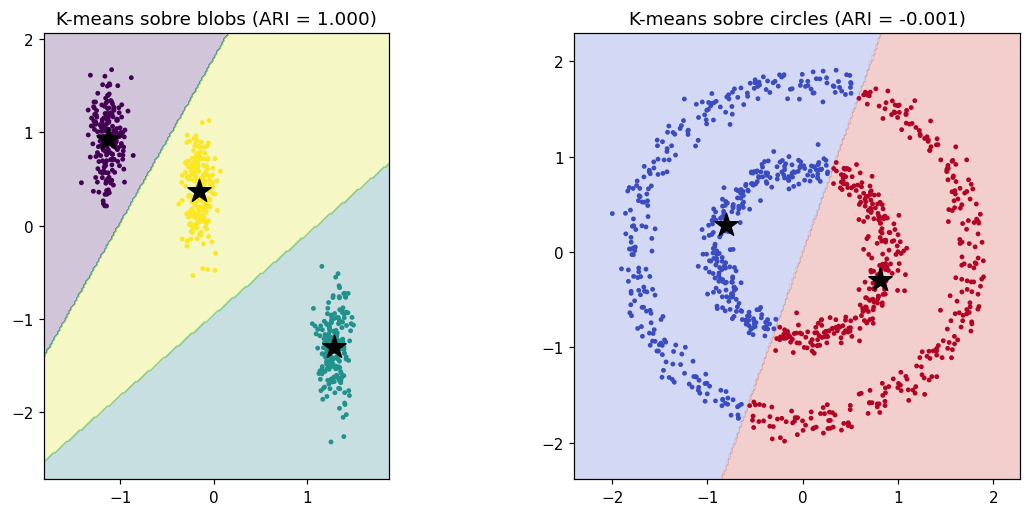

In [5]:
km_blobs = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(Xb)
km_circ = kmeans

xb, yb = malla(Xb)
region_b = km_blobs.predict(np.c_[xb.ravel(), yb.ravel()])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

axes[0].contourf(xb, yb, region_b.reshape(xb.shape), alpha=0.25, cmap="viridis")
axes[0].scatter(Xb[:, 0], Xb[:, 1], c=km_blobs.labels_, cmap="viridis", s=10, edgecolor="none")
axes[0].scatter(km_blobs.cluster_centers_[:, 0], km_blobs.cluster_centers_[:, 1],
                c="black", marker="*", s=250)
ari_b = metrics.adjusted_rand_score(yb_true, km_blobs.labels_)
axes[0].set_title(f"K-means sobre blobs (ARI = {ari_b:.3f})")
axes[0].set_aspect("equal")

axes[1].contourf(xx, yy, regiones["K-means"].reshape(xx.shape), alpha=0.25, cmap="coolwarm")
axes[1].scatter(X[:, 0], X[:, 1], c=km_circ.labels_, cmap="coolwarm", s=10, edgecolor="none")
axes[1].scatter(km_circ.cluster_centers_[:, 0], km_circ.cluster_centers_[:, 1],
                c="black", marker="*", s=250)
ari_c = metrics.adjusted_rand_score(y_true, km_circ.labels_)
axes[1].set_title(f"K-means sobre circles (ARI = {ari_c:.3f})")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

### 3.3 Prueba numerica de separabilidad lineal

Si un algoritmo es lineal, las etiquetas que produce deberian poder reproducirse con un clasificador lineal. Se entrena una regresion logistica (frontera lineal) para predecir las etiquetas de cada algoritmo a partir de `X`. Una exactitud cercana a 1 indica que la particion es linealmente separable; una cercana a 0.5 (con dos clases balanceadas) indica que no lo es.

Como referencia se incluyen las etiquetas reales de `circles`.

In [6]:
def separabilidad_lineal(X, etiquetas):
    valido = etiquetas != -1
    clf = LogisticRegression(max_iter=1000).fit(X[valido], etiquetas[valido])
    return clf.score(X[valido], etiquetas[valido])


entradas = dict(base)
entradas["Etiquetas reales (referencia)"] = y_true

separabilidad = pd.DataFrame({
    "Exactitud del clasificador lineal": {
        nombre: separabilidad_lineal(X, etiquetas) for nombre, etiquetas in entradas.items()
    }
})
display(separabilidad.round(3))

,Exactitud del clasificador lineal
K-means,1.000
DBSCAN,0.501
SpectralClustering,0.501
Etiquetas reales (referencia),0.501


## 4. Hiperparametros criticos de K-means

### 4.1 `n_clusters`

K-means necesita que se le indique el numero de grupos. Se barre `k` sobre `circles` y sobre `blobs` (que tiene 3 grupos reales). En `circles` ningun valor de `k` recupera los dos circulos, porque el problema es la naturaleza lineal del modelo y no el hiperparametro.

,ARI circles,ARI blobs,Silueta blobs
k,,,
2,-0.001,0.571,0.752
3,-0.001,1.000,0.719
4,-0.001,0.869,0.656
5,-0.001,0.727,0.607
6,-0.001,0.574,0.496
7,-0.000,0.532,0.487


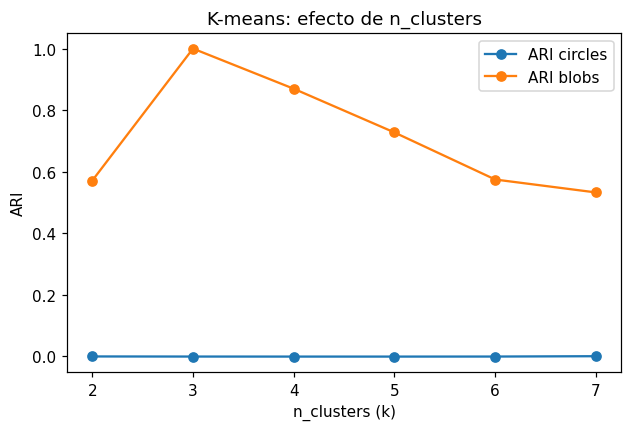

In [7]:
filas = []
for k in range(2, 8):
    lc = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X).labels_
    lb = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Xb).labels_
    filas.append({
        "k": k,
        "ARI circles": metrics.adjusted_rand_score(y_true, lc),
        "ARI blobs": metrics.adjusted_rand_score(yb_true, lb),
        "Silueta blobs": metrics.silhouette_score(Xb, lb),
    })

tabla_k = pd.DataFrame(filas).set_index("k")
display(tabla_k.round(3))

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(tabla_k.index, tabla_k["ARI circles"], marker="o", label="ARI circles")
ax.plot(tabla_k.index, tabla_k["ARI blobs"], marker="o", label="ARI blobs")
ax.set_xlabel("n_clusters (k)")
ax.set_ylabel("ARI")
ax.set_title("K-means: efecto de n_clusters")
ax.legend()
plt.show()

### 4.2 `init` y `n_init`

K-means solo garantiza un optimo local, por lo que el resultado depende de los centroides iniciales. Se compara la variabilidad de la inercia (menor es mejor) sobre 30 semillas distintas usando una inicializacion aleatoria con una sola ejecucion frente a `k-means++` con varias ejecuciones. Se usa un dataset con 6 grupos, donde los optimos locales son mas frecuentes.

In [8]:
Xh_raw, _ = make_blobs(n_samples=900, centers=6, cluster_std=1.1, random_state=3)
Xh = StandardScaler().fit_transform(Xh_raw)

configs = {
    "init=random, n_init=1": dict(init="random", n_init=1),
    "init=k-means++, n_init=1": dict(init="k-means++", n_init=1),
    "init=k-means++, n_init=10": dict(init="k-means++", n_init=10),
}

resumen = {}
for nombre, cfg in configs.items():
    inercias = [
        KMeans(n_clusters=6, random_state=semilla, **cfg).fit(Xh).inertia_
        for semilla in range(30)
    ]
    resumen[nombre] = {
        "Inercia media": np.mean(inercias),
        "Desv. estandar": np.std(inercias),
        "Minima": np.min(inercias),
        "Maxima": np.max(inercias),
    }

display(pd.DataFrame(resumen).T.round(3))

,Inercia media,Desv. estandar,Minima,Maxima
"init=random, n_init=1",73.804,13.339,69.393,144.171
"init=k-means++, n_init=1",72.363,2.958,69.388,75.543
"init=k-means++, n_init=10",69.392,0.008,69.387,69.430


## 5. Hiperparametros criticos de DBSCAN

DBSCAN no necesita el numero de clusters, pero depende de `eps` (radio de vecindad) y `min_samples` (vecinos necesarios para considerar una zona densa). Se evalua una grilla de ambos valores y se registra el ARI, el numero de clusters encontrados y la cantidad de puntos de ruido.

In [9]:
eps_vals = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50, 0.80]
min_vals = [3, 5, 10, 20, 50]

filas = []
for eps in eps_vals:
    for ms in min_vals:
        et = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)
        filas.append({
            "eps": eps,
            "min_samples": ms,
            "ARI": metrics.adjusted_rand_score(y_true, et),
            "Clusters": len(set(et) - {-1}),
            "Ruido": int((et == -1).sum()),
        })

grilla = pd.DataFrame(filas)
ari_pivot = grilla.pivot(index="min_samples", columns="eps", values="ARI")
clu_pivot = grilla.pivot(index="min_samples", columns="eps", values="Clusters")
rui_pivot = grilla.pivot(index="min_samples", columns="eps", values="Ruido")

print("ARI")
display(ari_pivot.round(3))
print("Numero de clusters")
display(clu_pivot)
print("Puntos de ruido")
display(rui_pivot)

ARI


eps,0.05,0.10,0.15,0.20,0.30,0.50,0.80
min_samples,,,,,,,
3,0.051,0.490,0.630,1.000,1.0,0.000,0.0
5,0.085,0.479,0.611,1.000,1.0,0.000,0.0
10,0.000,0.394,0.530,1.000,1.0,0.000,0.0
20,0.000,0.000,0.534,0.873,1.0,0.000,0.0
50,0.000,0.000,0.000,0.000,1.0,0.984,0.0


Numero de clusters


eps,0.05,0.10,0.15,0.20,0.30,0.50,0.80
min_samples,,,,,,,
3,92,25,5,2,2,1,1
5,33,34,6,2,2,1,1
10,0,13,16,2,2,1,1
20,0,0,6,4,2,1,1
50,0,0,0,0,1,1,1


Puntos de ruido


eps,0.05,0.10,0.15,0.20,0.30,0.50,0.80
min_samples,,,,,,,
3,436,47,3,0,0,0,0
5,739,105,7,0,0,0,0
10,1000,538,62,0,0,0,0
20,1000,1000,529,433,0,0,0
50,1000,1000,1000,1000,500,496,0


**Como leer el mapa de calor:** el ARI trata el ruido como un grupo mas, por lo que puede dar valores enganosos cuando DBSCAN encuentra un solo cluster y declara como ruido todo el otro circulo. Por eso solo se colorean las configuraciones que encontraron exactamente 2 clusters; las demas quedan en gris con el numero de clusters hallados.

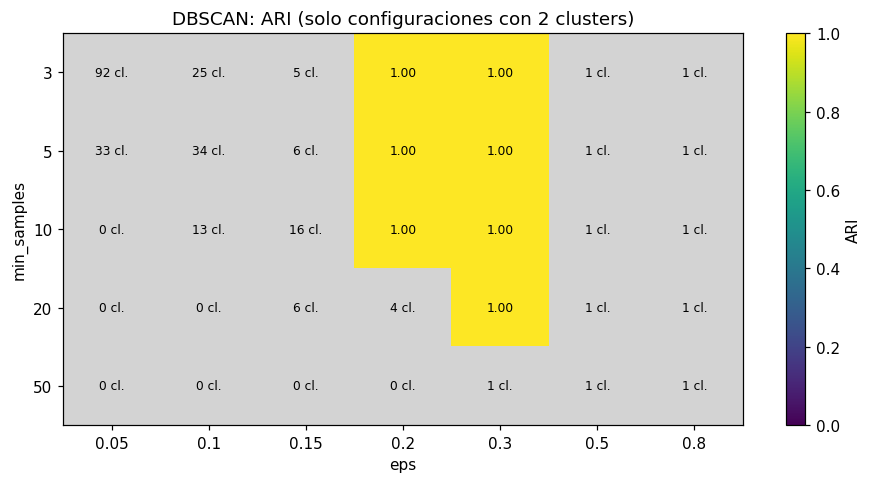

In [10]:
ari_valido = ari_pivot.where(clu_pivot == 2)
cmap = plt.get_cmap("viridis").copy()
cmap.set_bad("lightgray")

fig, ax = plt.subplots(figsize=(8.5, 4.5))
im = ax.imshow(np.ma.masked_invalid(ari_valido.values), cmap=cmap, vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(eps_vals)))
ax.set_xticklabels(eps_vals)
ax.set_yticks(range(len(min_vals)))
ax.set_yticklabels(min_vals)
ax.set_xlabel("eps")
ax.set_ylabel("min_samples")
ax.set_title("DBSCAN: ARI (solo configuraciones con 2 clusters)")
for i in range(ari_valido.shape[0]):
    for j in range(ari_valido.shape[1]):
        valor = ari_valido.values[i, j]
        if np.isnan(valor):
            texto, color = f"{int(clu_pivot.values[i, j])} cl.", "black"
        else:
            texto, color = f"{valor:.2f}", "white" if valor < 0.6 else "black"
        ax.text(j, i, texto, ha="center", va="center", color=color, fontsize=8)
fig.colorbar(im, ax=ax, label="ARI")
plt.tight_layout()
plt.show()

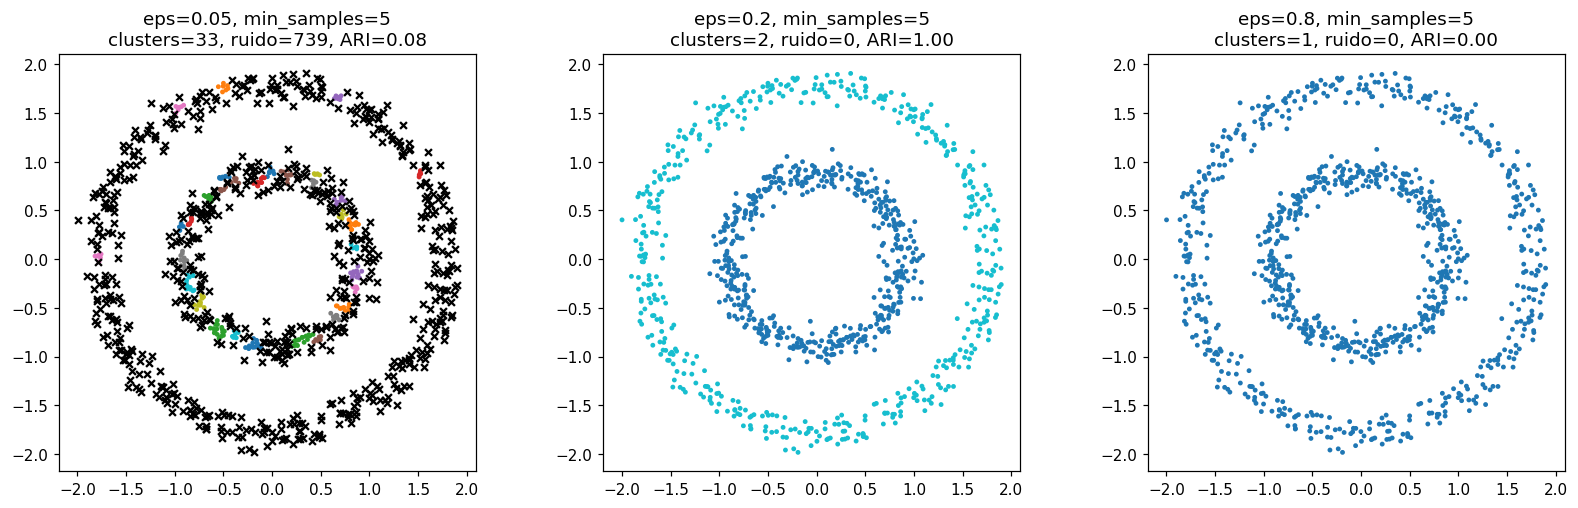

In [11]:
casos = [(0.05, 5), (0.20, 5), (0.80, 5)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (eps, ms) in zip(axes, casos):
    et = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)
    ruido = et == -1
    ax.scatter(X[~ruido, 0], X[~ruido, 1], c=et[~ruido], cmap="tab10", s=10, edgecolor="none")
    ax.scatter(X[ruido, 0], X[ruido, 1], c="black", marker="x", s=20)
    ari = metrics.adjusted_rand_score(y_true, et)
    ax.set_title(f"eps={eps}, min_samples={ms}\nclusters={len(set(et) - {-1})}, ruido={ruido.sum()}, ARI={ari:.2f}")
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 6. Hiperparametros criticos de SpectralClustering

SpectralClustering depende de `n_clusters` y, sobre todo, de como se construye la matriz de afinidad:

- `affinity="nearest_neighbors"`: grafo de vecinos; el parametro clave es `n_neighbors`.
- `affinity="rbf"`: kernel gaussiano; el parametro clave es `gamma` (a mayor `gamma`, mas local es la similitud).

Se mide el ARI para cada configuracion.

In [12]:
filas = []

for nn in [3, 5, 10, 20, 50]:
    et = ajustar_spectral(n_clusters=2, affinity="nearest_neighbors", n_neighbors=nn)
    filas.append({
        "affinity": "nearest_neighbors",
        "parametro": f"n_neighbors={nn}",
        "ARI": metrics.adjusted_rand_score(y_true, et),
    })

for g in [0.1, 1, 5, 10, 50]:
    et = ajustar_spectral(n_clusters=2, affinity="rbf", gamma=g)
    filas.append({
        "affinity": "rbf",
        "parametro": f"gamma={g}",
        "ARI": metrics.adjusted_rand_score(y_true, et),
    })

tabla_sp = pd.DataFrame(filas)
display(tabla_sp.round(3))

,affinity,parametro,ARI
0,nearest_neighbors,n_neighbors=3,0.039
1,nearest_neighbors,n_neighbors=5,0.352
2,nearest_neighbors,n_neighbors=10,1.000
3,nearest_neighbors,n_neighbors=20,1.000
4,nearest_neighbors,n_neighbors=50,1.000
5,rbf,gamma=0.1,-0.001
6,rbf,gamma=1,-0.001
7,rbf,gamma=5,-0.001
8,rbf,gamma=10,1.000
9,rbf,gamma=50,1.000


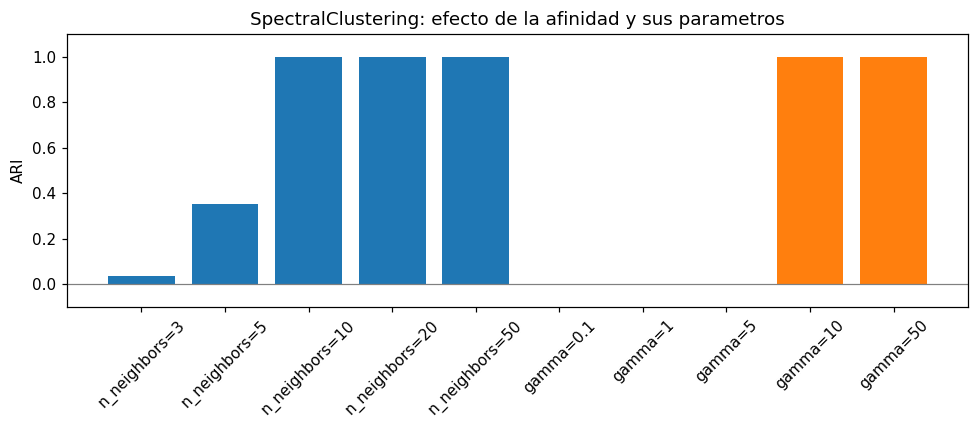

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
colores = ["tab:blue" if a == "nearest_neighbors" else "tab:orange" for a in tabla_sp["affinity"]]
ax.bar(tabla_sp["parametro"], tabla_sp["ARI"], color=colores)
ax.set_ylabel("ARI")
ax.set_ylim(-0.1, 1.1)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_title("SpectralClustering: efecto de la afinidad y sus parametros")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 7. Costo computacional

El caracter no lineal de DBSCAN y SpectralClustering tiene un costo en tiempo de ejecucion. Se mide el tiempo promedio de ajuste de cada modelo sobre `circles` (5 repeticiones).

In [14]:
def medir(funcion, repeticiones=5):
    tiempos = []
    for _ in range(repeticiones):
        inicio = time.perf_counter()
        funcion()
        tiempos.append(time.perf_counter() - inicio)
    return np.mean(tiempos)


tiempos = {
    "K-means": medir(lambda: KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit(X)),
    "DBSCAN": medir(lambda: DBSCAN(eps=0.2, min_samples=5).fit(X)),
    "SpectralClustering": medir(lambda: ajustar_spectral(
        n_clusters=2, affinity="nearest_neighbors", n_neighbors=10)),
}

tabla_t = pd.DataFrame({"Tiempo promedio (s)": tiempos})
display(tabla_t.round(4))

,Tiempo promedio (s)
K-means,0.0118
DBSCAN,0.0063
SpectralClustering,0.2709


## 8. Conclusiones

**Naturaleza de cada modelo (con evidencia de los experimentos)**

| Modelo | Naturaleza | Evidencia |
|---|---|---|
| K-means | Lineal | Sus regiones son poligonos convexos delimitados por rectas. Las etiquetas que produce son 100% separables por un clasificador lineal (exactitud 1.000). En `circles` obtiene ARI cercano a 0, y en `blobs` con k=3 obtiene ARI = 1.000 |
| DBSCAN | No lineal | Recupera los dos circulos (ARI = 1.000) con la configuracion adecuada. Un clasificador lineal solo alcanza 0.501 sobre sus etiquetas, igual que sobre las etiquetas reales: la particion correcta no es linealmente separable |
| SpectralClustering | No lineal | Mismo comportamiento que DBSCAN: ARI = 1.000 y separabilidad lineal de 0.501, porque separa por conectividad en el grafo y no por distancia a centroides |

**Hiperparametros criticos y hallazgos**

*K-means*
- `n_clusters`: en `blobs`, k=3 (el valor real) da ARI = 1.000, k=2 baja a 0.571 y k>3 sigue descendiendo. En `circles` ningun valor de k lo resuelve (ARI cercano a 0), porque el limite es la naturaleza lineal del modelo y no el hiperparametro. Ademas, la silueta en `blobs` fue mayor con k=2 (0.752) que con k=3 (0.719), por lo que no conviene elegir k usando solo la silueta.
- `init` y `n_init`: con inicializacion aleatoria y una sola ejecucion, la inercia vario mucho entre semillas (desviacion estandar 13.3, maximo 144.2 frente a un minimo de 69.4). Con `k-means++` la desviacion bajo a 2.96, y con `n_init=10` practicamente desaparecio (0.008). Son ajustes baratos que dan estabilidad.
- Todas las variables deben estar estandarizadas, porque K-means usa distancias euclidianas.

*DBSCAN*
- `eps`: es el mas sensible. Con `eps` pequeno (0.05 a 0.10) el algoritmo fragmenta los circulos en muchos clusters y genera mucho ruido. Con `eps` grande (>= 0.5) une ambos circulos en un solo cluster. La zona de exito en este dataset esta en `eps` entre 0.2 y 0.3.
- `min_samples`: si es demasiado alto, gran parte de los puntos pasa a ser ruido (con `min_samples=50` y `eps` <= 0.2 todos los puntos quedaron como ruido). Valores entre 3 y 10 funcionaron bien con `eps` = 0.2 y 0.3.
- Los dos hiperparametros interactuan, por lo que deben ajustarse juntos, apoyandose en el grafico de k-distancias.
- Precaucion al evaluar: el ARI cuenta el ruido como un grupo mas. Algunas configuraciones con un solo cluster y el otro circulo marcado como ruido obtienen un ARI alto sin haber separado realmente los dos circulos, por eso conviene revisar tambien el numero de clusters y de puntos de ruido.

*SpectralClustering*
- `n_clusters`: igual que en K-means, debe indicarse.
- `affinity` y sus parametros: es el hiperparametro decisivo. Con `nearest_neighbors`, `n_neighbors` = 3 y 5 fallaron (ARI = 0.000 y 0.164) y desde 10 recupero los circulos (ARI = 1.000). Con `rbf`, `gamma` <= 5 fallo (ARI cercano a 0) y `gamma` >= 10 funciono. Si el grafo de similitud es muy difuso o muy fragmentado, el resultado no refleja la estructura real.

**Costo computacional (ejecucion de referencia, 1000 puntos):** K-means 0.004 s, DBSCAN 0.003 s y SpectralClustering 0.093 s, unas 25 veces mas lento que los otros dos. Los tiempos exactos varian con el equipo, pero el orden se mantiene. El costo extra de SpectralClustering es el precio de la frontera no lineal.

**Conclusion general:** ningun modelo es mejor en abstracto. K-means es apropiado cuando los grupos son compactos y aproximadamente esfericos, y DBSCAN y SpectralClustering cuando tienen formas arbitrarias como los circulos concentricos. En los tres casos, un hiperparametro mal elegido (`k`, `eps` o `gamma`/`n_neighbors`) puede arruinar el resultado, por lo que su ajuste debe hacerse antes de interpretar el agrupamiento.